In [1]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [2]:
import pandas as pd

# Replace filename if needed
df = pd.read_csv('IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()
df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


In [4]:
# Convert sentiment to binary
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [5]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)   # remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df['review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['review'])

X = tokenizer.texts_to_sequences(df['review'])
X = pad_sequences(X, maxlen=max_len)

y = df['sentiment']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 123s 469ms/step - accuracy: 0.8416 - loss: 0.3631 - val_accuracy: 0.8805 - val_loss: 0.3054
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 114s 458ms/step - accuracy: 0.9194 - loss: 0.2118 - val_accuracy: 0.8741 - val_loss: 0.2954
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 459ms/step - accuracy: 0.9401 - loss: 0.1603 - val_accuracy: 0.8801 - val_loss: 0.3021


In [11]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8783 - loss: 0.3017
Test Accuracy: 0.8783000111579895


In [13]:
from tensorflow.keras.layers import Dropout, Bidirectional

model_tuned = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_tuned.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tuned.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_tuned = model_tuned.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 819s 2s/step - accuracy: 0.8320 - loss: 0.3855 - val_accuracy: 0.8779 - val_loss: 0.2977
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 794s 2s/step - accuracy: 0.9124 - loss: 0.2303 - val_accuracy: 0.8771 - val_loss: 0.3045
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 804s 2s/step - accuracy: 0.9358 - loss: 0.1749 - val_accuracy: 0.8687 - val_loss: 0.3701
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 808s 2s/step - accuracy: 0.9544 - loss: 0.1278 - val_accuracy: 0.8640 - val_loss: 0.3940
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.9676 - loss: 0.0956 - val_accuracy: 0.8616 - val_loss: 0.4579


In [15]:
loss_tuned, acc_tuned = model_tuned.evaluate(X_test, y_test)

print("Accuracy Before Tuning:", acc)
print("Accuracy After Tuning:", acc_tuned)

313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 337ms/step - accuracy: 0.8623 - loss: 0.4557
Accuracy Before Tuning: 0.8783000111579895
Accuracy After Tuning: 0.8622999787330627


In [16]:
sample_review = ["This movie was absolutely amazing and thrilling"]

sample_seq = tokenizer.texts_to_sequences(sample_review)
sample_pad = pad_sequences(sample_seq, maxlen=max_len)

prediction = model_tuned.predict(sample_pad)

print("Prediction:", "Positive" if prediction[0][0] > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step
Prediction: Positive


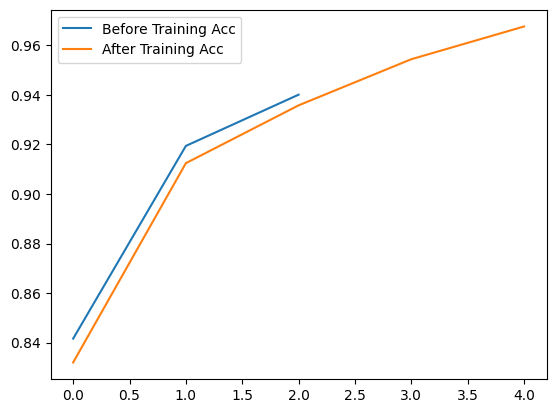

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Before Training Acc')
plt.plot(history_tuned.history['accuracy'], label='After Training Acc')
plt.legend()
plt.show()